<a href="https://colab.research.google.com/github/olando023/praca-projektowa-/blob/main/praca_projektowa_Medical_Cost_Personal_Datasets_(Insurance_Forecast).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. IMPORT BIBLIOTEK I POBRANIE DANYCH

In [33]:

# Importujemy niezbędne narzędzia do analizy i budowy modeli
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Pobieranie danych bezpośrednio z linku, zgodnie z wymogiem notatnika [cite: 8]
url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'
df = pd.read_csv(url)

print("Dane pobrane pomyślnie. Kształt zbioru:", df.shape)

Dane pobrane pomyślnie. Kształt zbioru: (1338, 7)


2. PODZIAŁ DANYCH NA ZBIÓR TRENINGOWY I TESTOWY

In [34]:

# Zawsze dzielimy dane przed analizą, aby nie sugerować się danymi testowymi.
# Używamy zmiennej 'charges' jako naszego celu (to chcemy przewidzieć).

X = df.drop("charges", axis=1) # Cechy (wszystko poza kosztami)
y = df["charges"].copy()       # Etykiety (tylko koszty)

# Wykonujemy podział (80% treningowe, 20% testowe)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Tworzymy kopię danych treningowych do wizualizacji
df_train = X_train.copy()
df_train["charges"] = y_train

3. WIZUALIZACJA I ANALIZA KORELACJI

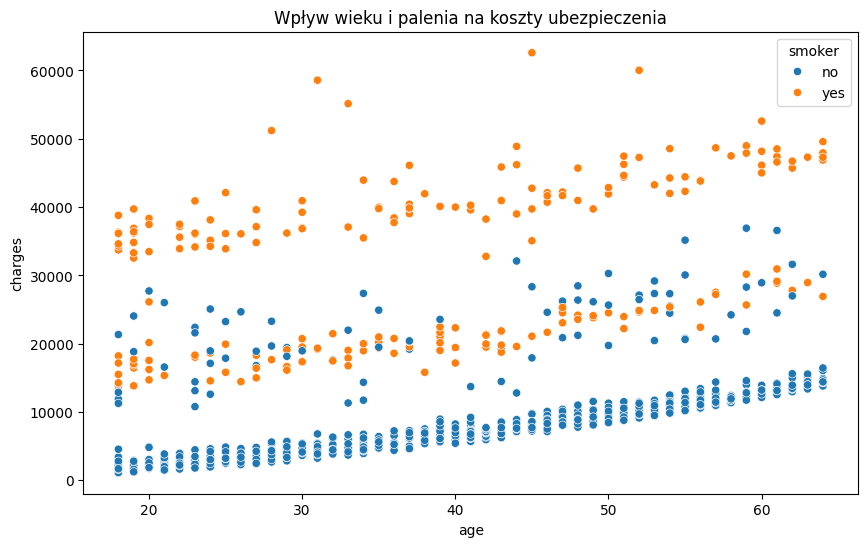

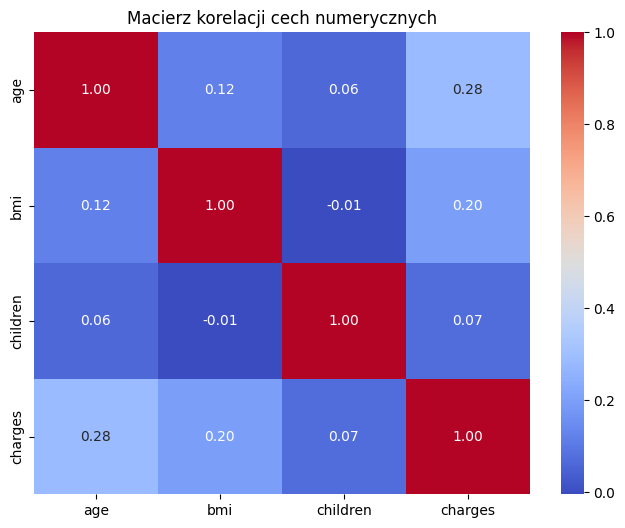


Najsilniejsza korelacja z kosztami (charges):
charges     1.000000
age         0.281721
bmi         0.197316
children    0.071885
Name: charges, dtype: float64


In [35]:

# 1. Wizualizacja: Sprawdzamy, jak palenie i wiek wpływają na koszty
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df_train)
plt.title("Wpływ wieku i palenia na koszty ubezpieczenia")
plt.show()

# 2. Analiza korelacji: Wybieramy tylko kolumny liczbowe, by zobaczyć matematyczne zależności
numeric_df = df_train.select_dtypes(include=[np.number])
korelacje = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(korelacje, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Macierz korelacji cech numerycznych")
plt.show()

print("\nNajsilniejsza korelacja z kosztami (charges):")
print(korelacje["charges"].sort_values(ascending=False))

4. CZYSZCZENIE I PRZYGOTOWANIE DANYCH (PIPELINES)

In [36]:

# Definiujemy, które kolumny są tekstowe, a które liczbowe
num_cols = ['age', 'bmi', 'children']
cat_cols = ['sex', 'smoker', 'region']

# Potok numeryczny: uzupełnia braki (mediana) i standaryzuje (skaluje) dane
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('scaler', StandardScaler())
])

# Potok kategoryczny: uzupełnia braki (moda) i zamienia tekst na liczby (OneHotEncoder)
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('onehot', OneHotEncoder(drop='first')) # drop='first' zabezpiecza przed błędem współliniowości
])

# Łączymy potoki w jeden główny transformator kolumn
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

# Przekształcamy dane treningowe (Model uczy się reguł przekształcania tutaj)
X_train_prepared = preprocessor.fit_transform(X_train)

5. IMPLEMENTACJA I PORÓWNANIE MODELI

In [37]:

# Zgodnie z wymaganiami trenujemy co najmniej dwa modele: Liniową Regresję i Las Losowy.

# 1. Regresja Liniowa (Linear Regression)
lin_reg = LinearRegression()
lin_reg.fit(X_train_prepared, y_train)

# Obliczamy błąd RMSE na danych treningowych
lin_predictions = lin_reg.predict(X_train_prepared)
lin_rmse = np.sqrt(mean_squared_error(y_train, lin_predictions))
print(f"Błąd RMSE dla Regresji Liniowej (Trening): {lin_rmse:.2f}")

# 2. Random Forest
forest_reg = RandomForestRegressor(random_state=42)
forest_reg.fit(X_train_prepared, y_train)

forest_predictions = forest_reg.predict(X_train_prepared)
forest_rmse = np.sqrt(mean_squared_error(y_train, forest_predictions))
print(f"Błąd RMSE dla Random Forest (Trening): {forest_rmse:.2f}")

Błąd RMSE dla Regresji Liniowej (Trening): 6105.55
Błąd RMSE dla Random Forest (Trening): 1931.37


6. AUTOMATYCZNY DOBÓR HIPERPARAMETRÓW (GRID SEARCH)

In [38]:

# Model Random Forest często jest przeuczony na starcie.
# Używamy Grid Search, aby znaleźć najlepsze ustawienia parametrów dla lasu.

param_grid = [
    # Próbujemy różnych kombinacji liczby drzew (n_estimators) i max_features
    {'n_estimators': [30, 50, 100], 'max_features': [2, 4, 6]}
]

# Inicjalizujemy poszukiwania (cv=5 oznacza 5-krotną walidację krzyżową)
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid,
                           cv=5, scoring='neg_mean_squared_error', return_train_score=True)

# Uruchamiamy poszukiwania najlepszego modelu
grid_search.fit(X_train_prepared, y_train)

print(f"Najlepsze hiperparametry znalezione przez GridSearch: {grid_search.best_params_}")

# Pobieramy najlepszy wyuczony model
best_model = grid_search.best_estimator_

Najlepsze hiperparametry znalezione przez GridSearch: {'max_features': 4, 'n_estimators': 100}


7. WYNIK KOŃCOWY NA ZBIORZE TESTOWYM I WNIOSKI

In [39]:

# Czas przetestować nasz najlepszy model na danych testowych, których nigdy nie widział.

# UWAGA: Używamy tylko .transform(), aby zastosować te same skale, których nauczono się na treningu.
X_test_prepared = preprocessor.transform(X_test)

# Predykcja
final_predictions = best_model.predict(X_test_prepared)

# Ocena za pomocą RMSE
final_rmse = np.sqrt(mean_squared_error(y_test, final_predictions))

print(f"OSTATECZNY BŁĄD RMSE NA ZBIORZE TESTOWYM: {final_rmse:.2f}")

# Wniosek: Porównanie
# Regresja Liniowa osiągnęła większy błąd, nie potrafiąc uchwycić złożonych relacji (np. skoku kosztów dla palaczy z wysokim BMI).
# Las Losowy (Random Forest), po zoptymalizowaniu parametrów przez GridSearchCV, okazał się lepszym modelem,
# uzyskując najniższy błąd na odłożonym zbiorze testowym.

OSTATECZNY BŁĄD RMSE NA ZBIORZE TESTOWYM: 4461.84


8. PRZEWIDYWANIE KOSZTÓW DLA NOWEGO PACJENTA

In [40]:


# 1. Wpisujemy dane ręcznie do słownika.
# Zwróć uwagę, że wartości muszą być w nawiasach kwadratowych [ ]
nowy_pacjent = {
    'age': [60],             # Wiek (liczba całkowita)
    'sex': ['male'],         # Płeć: 'male' lub 'female'
    'bmi': [50.5],           # BMI (liczba, używamy kropki dla ułamków)
    'children': [0],         # Liczba dzieci (liczba całkowita)
    'smoker': ['yes'],       # Czy pali: 'yes' lub 'no'
    'region': ['southwest']  # Region: 'southwest', 'southeast', 'northwest', 'northeast'
}

# 2. Zamieniamy słownik na ramkę danych (DataFrame)
nowy_pacjent_df = pd.DataFrame(nowy_pacjent)

print("Dane wprowadzone przez Ciebie:")
display(nowy_pacjent_df)

# 3. Przepuszczamy dane przez nasz potok (Pipeline)
# UWAGA: Używamy metody .transform(), a NIE .fit_transform()!
# Dzięki temu potok używa dokładnie tego samego kodowania i skalowania co na danych treningowych.
nowy_pacjent_prepared = preprocessor.transform(nowy_pacjent_df)

# 4. Dokonujemy predykcji naszym najlepszym modelem (Las Losowy wyłoniony przez Grid Search)
przewidywany_koszt = best_model.predict(nowy_pacjent_prepared)

print(f"\n---> Przewidywany roczny koszt ubezpieczenia to: {przewidywany_koszt[0]:.2f} $ <---")

Dane wprowadzone przez Ciebie:


,age,sex,bmi,children,smoker,region
0,60,male,50.5,0,yes,southwest



---> Przewidywany roczny koszt ubezpieczenia to: 47061.40 $ <---
